In [1]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

D:\Anaconda\envs\torchgpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
DATA_PATH = DATA_DIR / "ori_pqal.json"

LABEL2ID = {"yes": 0, "no": 1, "maybe": 2}
ID2LABEL = {0: "yes", 1: "no", 2: "maybe"}

MODEL_NAME = "google/flan-t5-xl"

In [3]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [4]:
def build_prompt(example):
    question = example["QUESTION"]
    context = " ".join(example["CONTEXTS"])
    prompt = (
        f"Question: {question}\n\n"
        f"Context: {context}\n\n"
        f"Based only on the context, answer the question with exactly one word: yes, no, or maybe."
    )
    return prompt

In [5]:
def dataset_to_lists(dataset_dict):
    pmids = []
    prompts = []
    labels = []

    for pmid, example in dataset_dict.items():
        pmids.append(pmid)
        prompts.append(build_prompt(example))
        labels.append(LABEL2ID[example["final_decision"]])

    return pmids, prompts, np.array(labels)

In [6]:
def normalize_prediction(text):
    text = text.strip().lower()

    text = re.sub(r"[^a-z\s]", " ", text)
    text = " ".join(text.split())

    if text.startswith("yes"):
        return "yes"
    if text.startswith("no"):
        return "no"
    if text.startswith("maybe"):
        return "maybe"

    # fallback: search inside the text
    if "maybe" in text:
        return "maybe"
    if "yes" in text:
        return "yes"
    if "no" in text:
        return "no"

    # if completely invalid, map to maybe as a fallback
    return "maybe"

In [7]:
def generate_predictions(prompts, tokenizer, model, device, max_samples=None):
    predictions = []

    if max_samples is not None:
        prompts = prompts[:max_samples]

    for i, prompt in enumerate(prompts):
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=5
        )

        generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        pred_label = normalize_prediction(generated_text)
        predictions.append(pred_label)

        if (i + 1) % 20 == 0:
            print(f"Processed {i + 1} samples")

    return predictions

In [8]:
def main():
    data = load_json(DATA_PATH)
    pmids, prompts, labels = dataset_to_lists(data)

    X_train_prompts, X_test_prompts, y_train, y_test = train_test_split(
        prompts,
        labels,
        test_size=0.3,
        random_state=42,
        stratify=labels
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Using device:", device)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
    model.eval()
    # first test on a small subset if needed
    y_pred_text = generate_predictions(X_test_prompts, tokenizer, model, device)
    y_pred = np.array([LABEL2ID[p] for p in y_pred_text])

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    print("\n=== Answer Generation Results (70/30 split) ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")

    print("\n=== Classification Report ===")
    print(classification_report(y_test, y_pred, target_names=["yes", "no", "maybe"]))

    plot_conf_matrix(y_test, y_pred, ["yes", "no", "maybe"], "FLAN-T5-large Confusion Matrix")
    plot_metric_bar(acc, macro_f1)

In [9]:
def plot_conf_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(values_format="d")
    plt.title(title)
    plt.show()
def plot_metric_bar(acc, macro_f1):
    metrics = ["Accuracy", "Macro-F1"]
    values = [acc, macro_f1]

    plt.figure(figsize=(6, 5))
    plt.bar(metrics, values)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title("FLAN-T5-large Performance")
    plt.show()

Using device: cuda


Loading weights: 100%|██████████| 558/558 [00:00<00:00, 2582.50it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
D:\Anaconda\envs\torchgpu\lib\site-packages\torch\cuda\__init__.py:287: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


Processed 20 samples
Processed 40 samples
Processed 60 samples
Processed 80 samples
Processed 100 samples
Processed 120 samples
Processed 140 samples
Processed 160 samples
Processed 180 samples
Processed 200 samples
Processed 220 samples
Processed 240 samples
Processed 260 samples
Processed 280 samples
Processed 300 samples

=== Answer Generation Results (70/30 split) ===
Accuracy: 0.7233
Macro-F1: 0.5190

=== Classification Report ===
              precision    recall  f1-score   support

         yes       0.77      0.84      0.80       166
          no       0.74      0.77      0.75       101
       maybe       0.00      0.00      0.00        33

    accuracy                           0.72       300
   macro avg       0.50      0.54      0.52       300
weighted avg       0.68      0.72      0.70       300



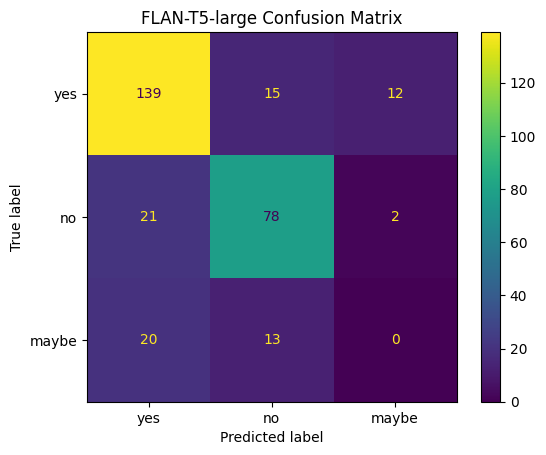

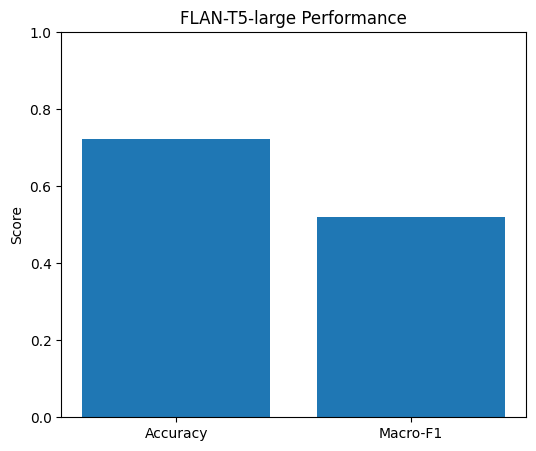

In [10]:
main()